In [9]:
import SimpleITK as sitk
import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
import pandas as pd
import seaborn as sns
from calibration import get_ece
from medpy.metric.binary import dc as dice_score
from sklearn.calibration import calibration_curve

sns.set_style('whitegrid')

## Whole-image metrics
Dice

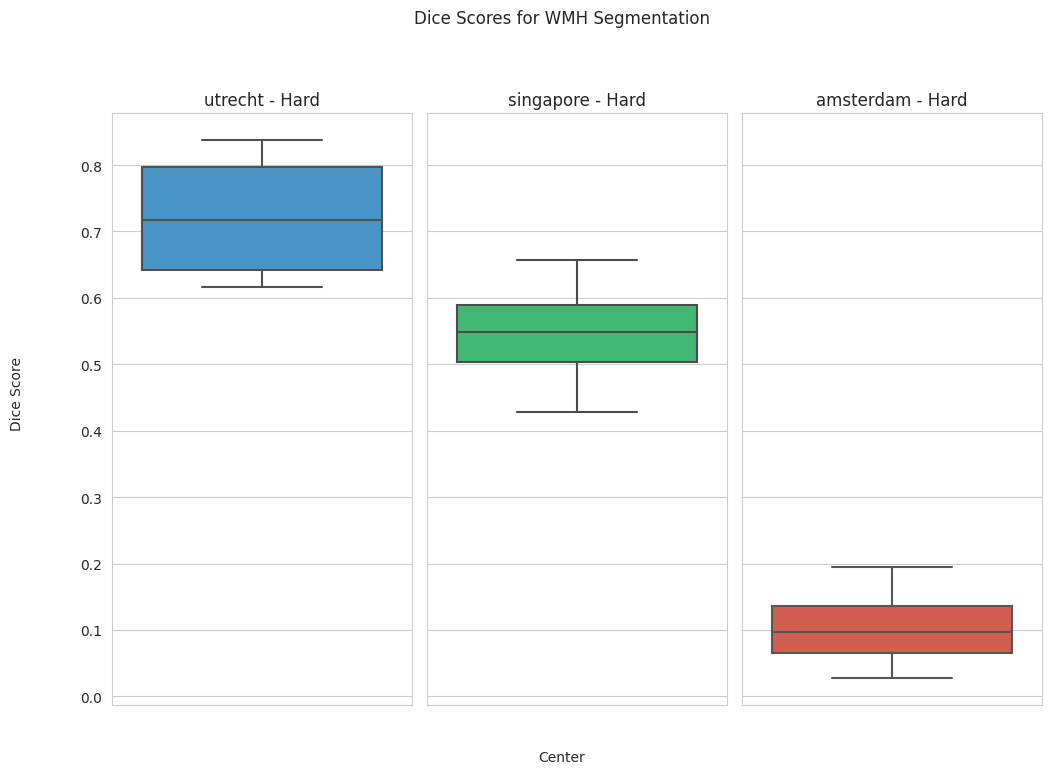

In [10]:
# Define colors for each center
colors = ['#3498db', '#2ecc71', '#e74c3c']

centers = ['utrecht', 'singapore', 'amsterdam']
dc = {}

for center in centers:
    df = pd.read_csv(f"utrecht-{center}.csv", header=None)
    df.columns = ['pred_wmh_hard', 'pred_wmh_softmax', 'pred_logits', 'gt_wmh']
    dc[center] = {'hard': []}

    for _, row in df.iterrows():
        pred_hard_path, pred_softmax_path, logits_path, gt_path = row

        pred_hard = nib.load(pred_hard_path).get_fdata()
        gt = nib.load(gt_path).get_fdata()

        # Compute dice scores
        dice_hard = dice_score(pred_hard, gt)

        # Save results in dictionary
        dc[center]['hard'].append(dice_hard)

# Create subplots using seaborn's boxplot
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(12, 8), sharey=True)
for i, center in enumerate(centers):
    sns.boxplot(y=dc[center]['hard'], color=colors[i], ax=axs[i])
    axs[i].set_title(f"{center} - Hard")

# Set axis labels and title
fig.suptitle('Dice Scores for WMH Segmentation')
fig.text(0.5, 0.04, 'Center', ha='center')
fig.text(0.04, 0.5, 'Dice Score', va='center', rotation='vertical')

# Adjust layout and save plot
fig.subplots_adjust(top=0.85, wspace=0.05)
plt.savefig('dice_scores.png', dpi=300, bbox_inches='tight')

## Class-wise metrics
Here the voxels are separated according to their class (0 or 1) and the metrics are computed for each class separately.
- Probabilities histogram from the softmax output
- Absolute logit values histogram
- Reliability diagram + ECE

### Probabilities histogram

Processing /home/franco/Code/datasets/wmh/training/Utrecht/35/pred_wmh_softmax_training_Utrecht_best.nii.gz...
Processing /home/franco/Code/datasets/wmh/training/Utrecht/29/pred_wmh_softmax_training_Utrecht_best.nii.gz...
Processing /home/franco/Code/datasets/wmh/training/Utrecht/25/pred_wmh_softmax_training_Utrecht_best.nii.gz...
Processing /home/franco/Code/datasets/wmh/training/Utrecht/33/pred_wmh_softmax_training_Utrecht_best.nii.gz...
Processing /home/franco/Code/datasets/wmh/training/Singapore/67/pred_wmh_softmax_training_Utrecht_best.nii.gz...
Processing /home/franco/Code/datasets/wmh/training/Singapore/63/pred_wmh_softmax_training_Utrecht_best.nii.gz...
Processing /home/franco/Code/datasets/wmh/training/Singapore/50/pred_wmh_softmax_training_Utrecht_best.nii.gz...
Processing /home/franco/Code/datasets/wmh/training/Singapore/68/pred_wmh_softmax_training_Utrecht_best.nii.gz...
Processing /home/franco/Code/datasets/wmh/training/Amsterdam/GE3T/106/pred_wmh_softmax_training_Utrecht_

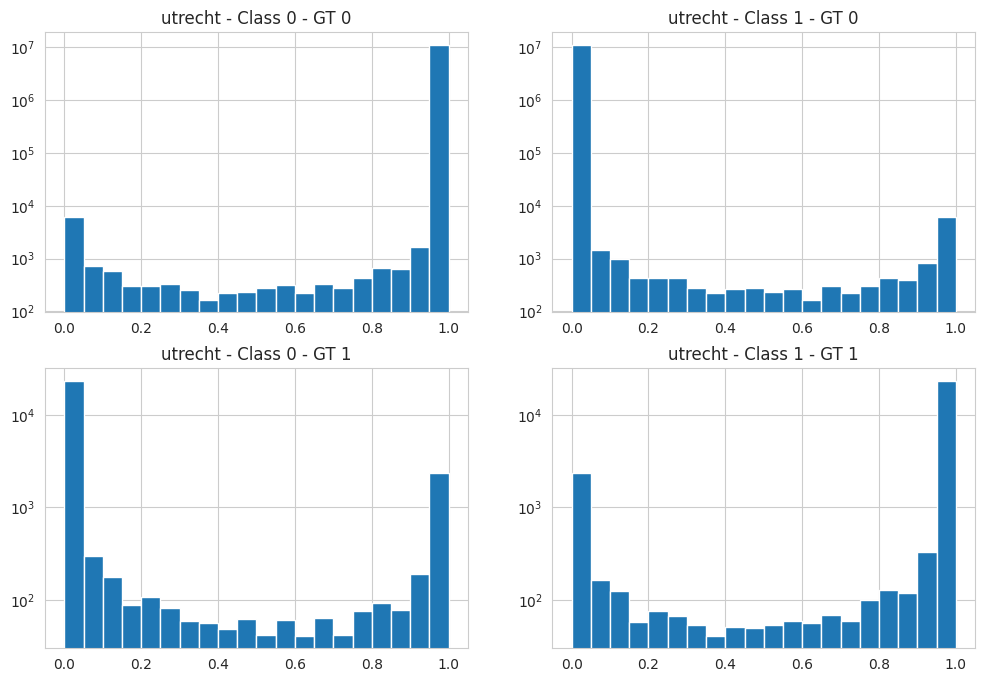

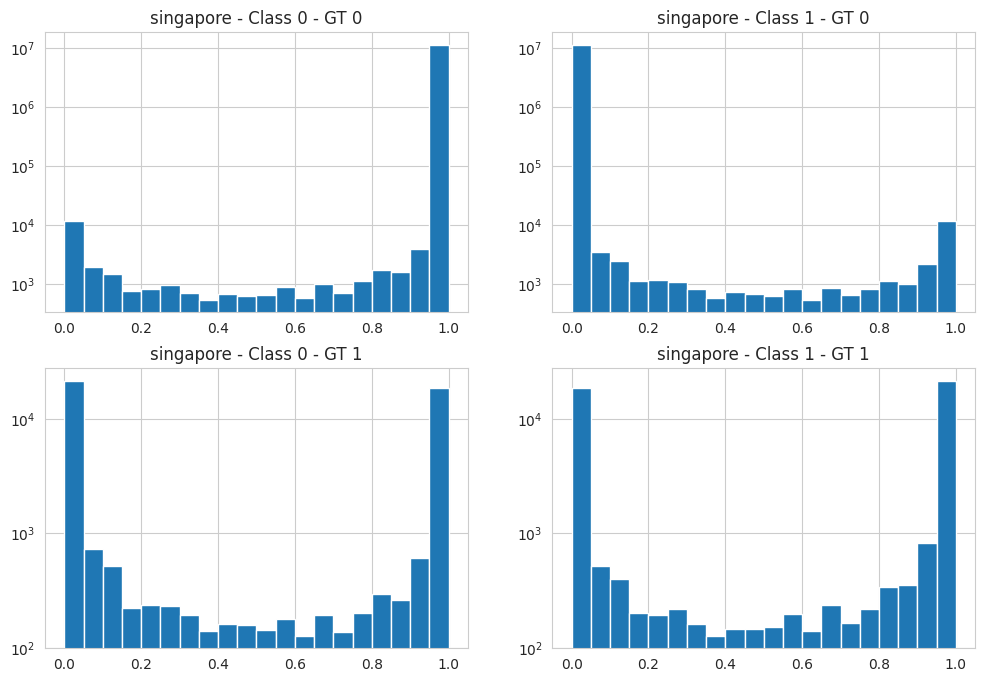

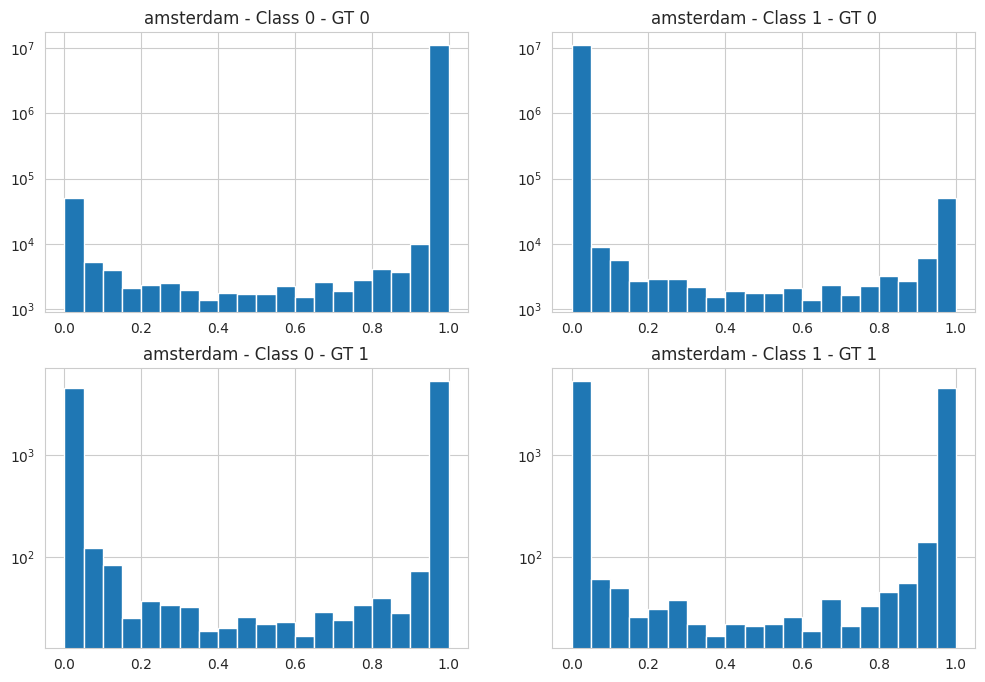

In [11]:
centers = ['utrecht', 'singapore', 'amsterdam']

for center in centers:
    imgs_smx_0_0, imgs_smx_0_1, imgs_smx_1_0, imgs_smx_1_1 = \
        np.array([]), np.array([]), np.array([]), np.array([])

    df = pd.read_csv(f"utrecht-{center}.csv", header=None)
    df.columns = ['pred_wmh_hard', 'pred_wmh_softmax', 'pred_logits', 'gt_wmh']

    for _, row in df.iterrows():
        _, pred_wmh_softmax, _, gt_wmh = row
        print(f"Processing {pred_wmh_softmax}...")

        # dims: [H, W, C, B, D]
        pred_softmax = nib.load(pred_wmh_softmax).get_fdata()
        gt = nib.load(gt_wmh).get_fdata().flatten()

        gt_0 = np.where(gt == 0)[0]
        gt_1 = np.where(gt == 1)[0]

        # get the softmax values for the voxels where gt is 1 in each channel
        img_smx_0_0 = pred_softmax[:, :, :, 0].flatten()[gt_0]
        img_smx_1_0 = pred_softmax[:, :, :, 1].flatten()[gt_0]
        img_smx_0_1 = pred_softmax[:, :, :, 0].flatten()[gt_1]
        img_smx_1_1 = pred_softmax[:, :, :, 1].flatten()[gt_1]

        # Concatenate sampled voxels for each class
        imgs_smx_0_0 = np.concatenate((imgs_smx_0_0, np.around(np.array(img_smx_0_0), decimals=2)))
        imgs_smx_1_0 = np.concatenate((imgs_smx_1_0, np.around(np.array(img_smx_1_0), decimals=2)))
        imgs_smx_0_1 = np.concatenate((imgs_smx_0_1, np.around(np.array(img_smx_0_1), decimals=2)))
        imgs_smx_1_1 = np.concatenate((imgs_smx_1_1, np.around(np.array(img_smx_1_1), decimals=2)))

    # Plot histogram for each voxel class
    fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))
    axs[0, 0].hist(imgs_smx_0_0, bins=20)
    axs[0, 0].set_yscale('log')
    axs[0, 0].set_title(f"{center} - Class 0 - GT 0")
    axs[0, 1].hist(imgs_smx_1_0, bins=20)
    axs[0, 1].set_yscale('log')
    axs[0, 1].set_title(f"{center} - Class 1 - GT 0")
    axs[1, 0].hist(imgs_smx_0_1, bins=20)
    axs[1, 0].set_yscale('log')
    axs[1, 0].set_title(f"{center} - Class 0 - GT 1")
    axs[1, 1].hist(imgs_smx_1_1, bins=20)
    axs[1, 1].set_yscale('log')
    axs[1, 1].set_title(f"{center} - Class 1 - GT 1")


### Absolute logit values histogram

Processing /home/franco/Code/datasets/wmh/training/Utrecht/35/pred_logits_training_Utrecht_best.nii.gz...
Processing /home/franco/Code/datasets/wmh/training/Utrecht/29/pred_logits_training_Utrecht_best.nii.gz...
Processing /home/franco/Code/datasets/wmh/training/Utrecht/25/pred_logits_training_Utrecht_best.nii.gz...
Processing /home/franco/Code/datasets/wmh/training/Utrecht/33/pred_logits_training_Utrecht_best.nii.gz...
Processing /home/franco/Code/datasets/wmh/training/Singapore/67/pred_logits_training_Utrecht_best.nii.gz...
Processing /home/franco/Code/datasets/wmh/training/Singapore/63/pred_logits_training_Utrecht_best.nii.gz...
Processing /home/franco/Code/datasets/wmh/training/Singapore/50/pred_logits_training_Utrecht_best.nii.gz...
Processing /home/franco/Code/datasets/wmh/training/Singapore/68/pred_logits_training_Utrecht_best.nii.gz...
Processing /home/franco/Code/datasets/wmh/training/Amsterdam/GE3T/106/pred_logits_training_Utrecht_best.nii.gz...
Processing /home/franco/Code/d

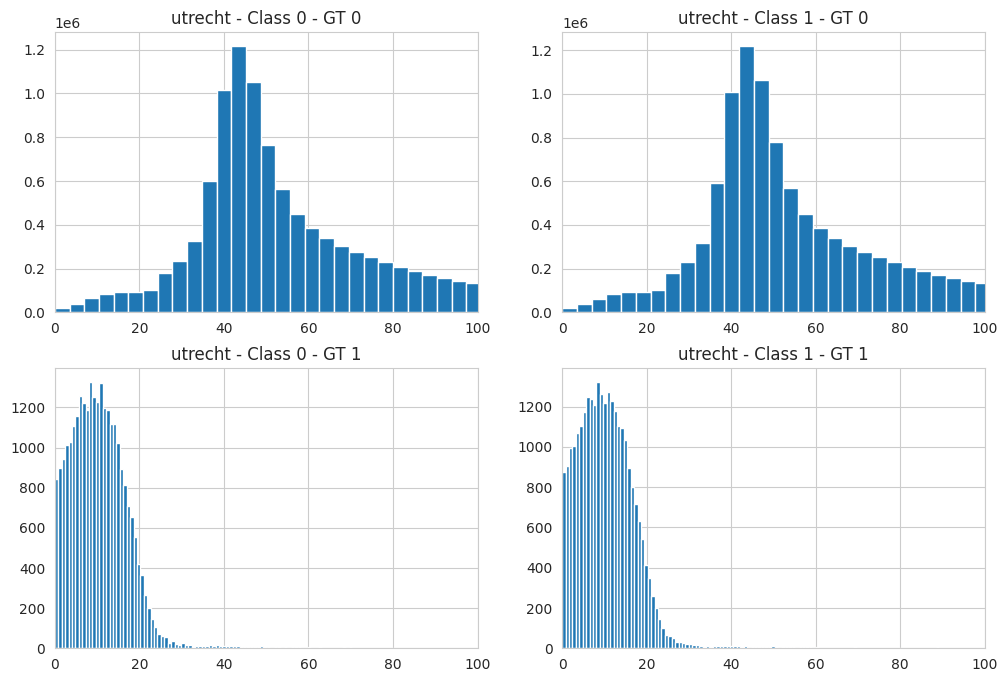

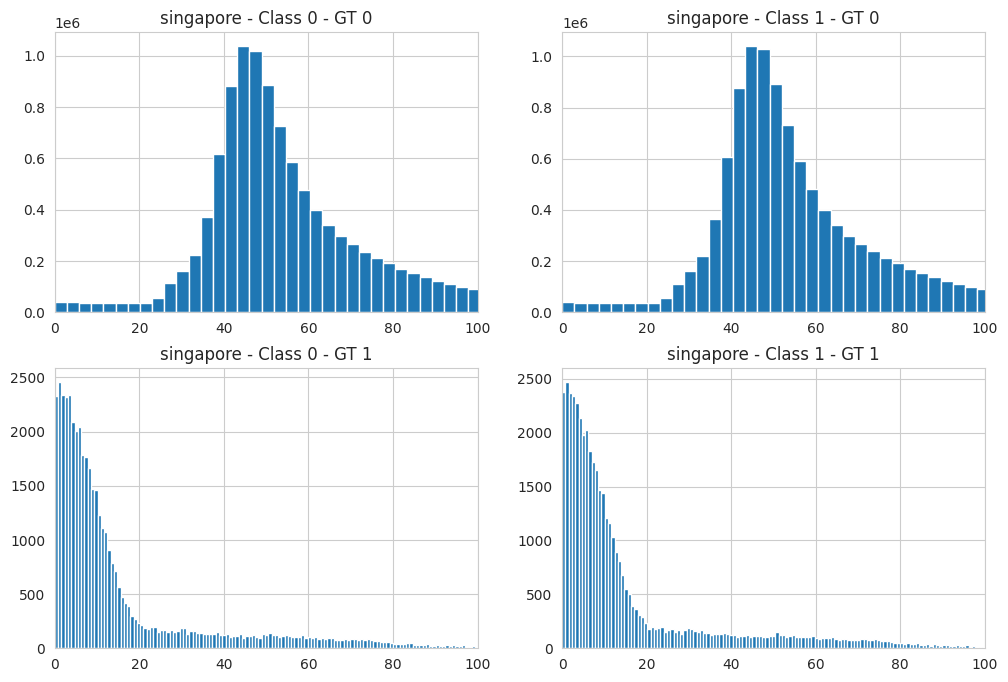

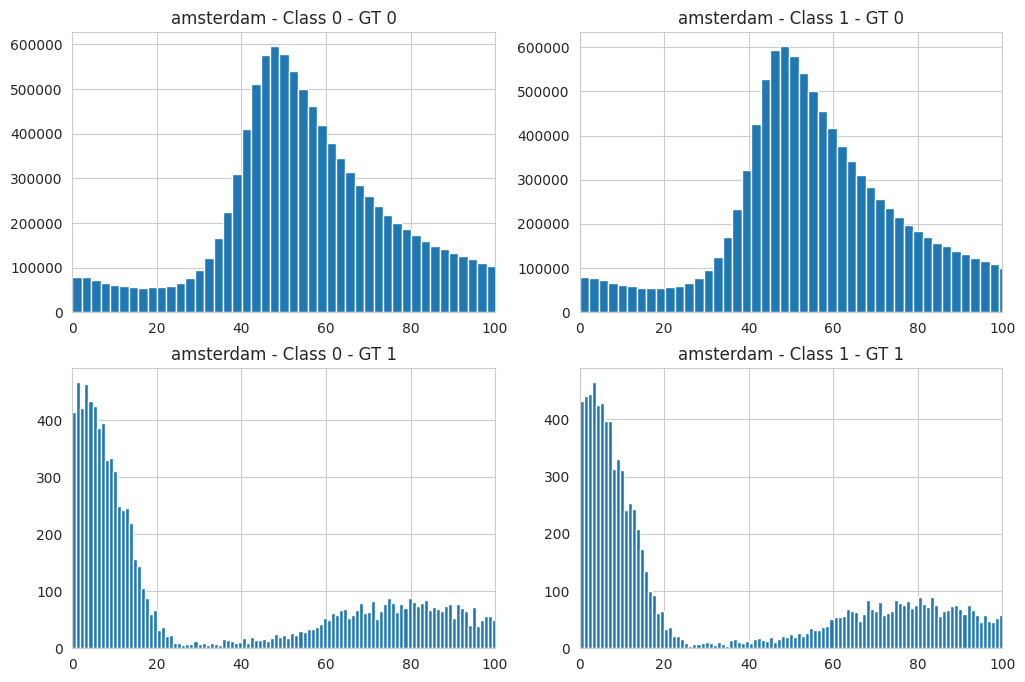

In [12]:
# Following the same logic as above, but now we get the absolute logit values
# for each voxel class
centers = ['utrecht', 'singapore', 'amsterdam']

for center in centers:
    imgs_logits_0_0, imgs_logits_0_1, imgs_logits_1_0, imgs_logits_1_1 = \
        np.array([]), np.array([]), np.array([]), np.array([])

    df = pd.read_csv(f"utrecht-{center}.csv", header=None)
    df.columns = ['pred_wmh_hard', 'pred_wmh_softmax', 'pred_logits', 'gt_wmh']

    for _, row in df.iterrows():
        _, _, pred_logits, gt_wmh = row
        print(f"Processing {pred_logits}...")

        # dims: [H, W, C, B, D]
        pred_logits = nib.load(pred_logits).get_fdata()
        gt = nib.load(gt_wmh).get_fdata().flatten()

        gt_0 = np.where(gt == 0)[0]
        gt_1 = np.where(gt == 1)[0]

        # get the absolute logit values for the voxels where gt is 1 in each channel
        img_logits_0_0 = np.abs(pred_logits[:, :, :, 0].flatten()[gt_0])
        img_logits_1_0 = np.abs(pred_logits[:, :, :, 1].flatten()[gt_0])
        img_logits_0_1 = np.abs(pred_logits[:, :, :, 0].flatten()[gt_1])
        img_logits_1_1 = np.abs(pred_logits[:, :, :, 1].flatten()[gt_1])

        # Concatenate sampled voxels for each class
        imgs_logits_0_0 = np.concatenate((imgs_logits_0_0, np.around(np.array(img_logits_0_0), decimals=2)))
        imgs_logits_1_0 = np.concatenate((imgs_logits_1_0, np.around(np.array(img_logits_1_0), decimals=2)))
        imgs_logits_0_1 = np.concatenate((imgs_logits_0_1, np.around(np.array(img_logits_0_1), decimals=2)))
        imgs_logits_1_1 = np.concatenate((imgs_logits_1_1, np.around(np.array(img_logits_1_1), decimals=2)))

    # Save biggest value in all imgs_logits to use as xlim
    # max_val = max([max(imgs_logits_0_0), max(imgs_logits_1_0), max(imgs_logits_0_1), max(imgs_logits_1_1)])
    max_val = 100

    # Plot histogram for each voxel class
    fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))

    axs[0, 0].hist(imgs_logits_0_0, bins=200)
    axs[0, 0].set_xlim([0, max_val])
    axs[0, 0].set_title(f"{center} - Class 0 - GT 0")

    axs[0, 1].hist(imgs_logits_1_0, bins=200)
    axs[0, 1].set_xlim([0, max_val])
    axs[0, 1].set_title(f"{center} - Class 1 - GT 0")

    axs[1, 0].hist(imgs_logits_0_1, bins=200)
    axs[1, 0].set_xlim([0, max_val])
    axs[1, 0].set_title(f"{center} - Class 0 - GT 1")

    axs[1, 1].hist(imgs_logits_1_1, bins=200)
    axs[1, 1].set_xlim([0, max_val])
    axs[1, 1].set_title(f"{center} - Class 1 - GT 1")

### ECE and reliability diagrams

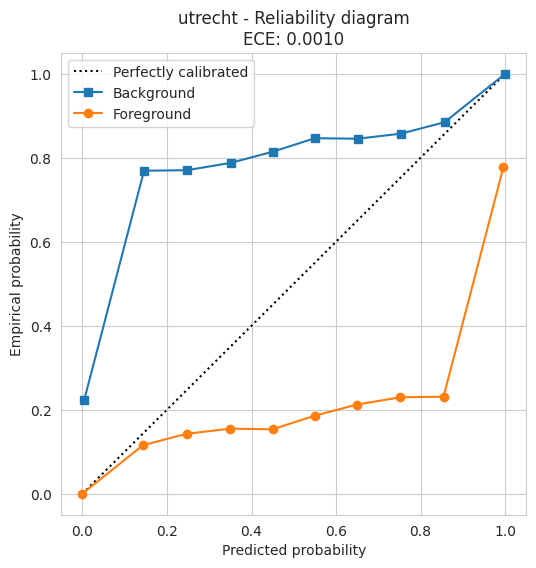

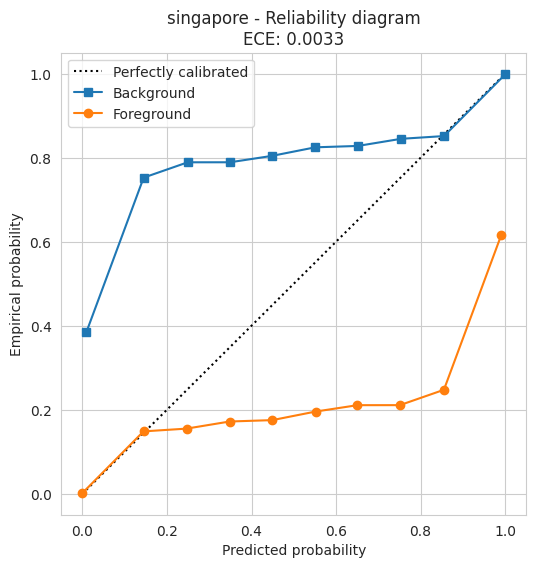

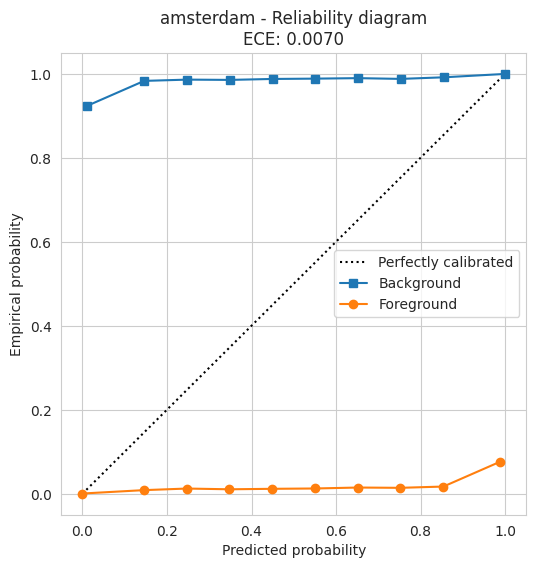

In [13]:
centers = ['utrecht', 'singapore', 'amsterdam']
for center in centers:
    df = pd.read_csv(f"utrecht-{center}.csv", header=None)
    df.columns = ['pred_wmh_hard', 'pred_wmh_softmax', 'pred_logits', 'gt_wmh']

    preds_0 = np.array([])
    preds_1 = np.array([])
    gt_0 = np.array([], dtype=np.uint8)
    gt_1 = np.array([], dtype=np.uint8)

    for i, row in df.iterrows():
        _, pred_wmh_softmax, _, gt_wmh = row

        pred_softmax = sitk.GetArrayFromImage(sitk.ReadImage(pred_wmh_softmax))
        gt_wmh = sitk.GetArrayFromImage(sitk.ReadImage(gt_wmh))

        # One-hot encode the ground truth labels
        gt_one_hot = np.eye(2, dtype=np.uint8)[gt_wmh.astype(int)]

        # Flatten the arrays and append to numpy array
        preds_0 = np.concatenate((preds_0, pred_softmax[0].flatten()))
        preds_1 = np.concatenate((preds_1, pred_softmax[1].flatten()))
        gt_0 = np.concatenate((gt_0, gt_one_hot[:, :, :, 0].flatten()))
        gt_1 = np.concatenate((gt_1, gt_one_hot[:, :, :, 1].flatten()))

    # Define the number of bins for the reliability diagram
    num_bins = 10

    # Calculate the bin edges
    bin_edges = np.linspace(0, 1, num_bins + 1)

    # Calculate the empirical probabilities and predicted probabilities for each bin
    empirical_probs_0, predicted_probs_0 = calibration_curve(gt_0, preds_0,
                                                             n_bins=num_bins)
    empirical_probs_1, predicted_probs_1 = calibration_curve(gt_1, preds_1,
                                                             n_bins=num_bins)

    # Calculate the expected calibration error (ECE)
    ece_0 = get_ece(preds_0, gt_0)
    # ece_1 = get_ece(preds_1, gt_1)  # same as ece_0

    # Plot the reliability diagram
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.plot([0, 1], [0, 1], 'k:', label='Perfectly calibrated')
    ax.plot(predicted_probs_0, empirical_probs_0, 's-', label='Background')
    ax.plot(predicted_probs_1, empirical_probs_1, 'o-', label='Foreground')
    ax.set_xlabel('Predicted probability')
    ax.set_ylabel('Empirical probability')
    # ax.set_ylim([-0.05, 1.05])
    ax.legend()
    ax.set_title(f"{center} - Reliability diagram\nECE: {ece_0:.4f}")